In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import random
from dataclasses import dataclass
import matplotlib.pyplot as plt
from multiarm_bandits import KArmBanditsConfig, KArmBandits, initialize_bandits

In [7]:
def run_experiments(k, epsilon, bandits, steps=1000, nums=200):
    karm_bandits = KArmBandits(k, epsilon, bandits)
    reward_result = []
    optimal_ratio_result = []
    for _ in range(nums):
        karm_bandits.reset()
        avg_reward, optimal_ratio = karm_bandits.play(steps)
        reward_result.append(avg_reward)
        optimal_ratio_result.append(optimal_ratio)
    
    return np.array(reward_result), np.array(optimal_ratio_result)

## reward std = 1.0

In [8]:
config = KArmBanditsConfig(k=10, max_reward=3, min_reward=-3, reward_std=1.0)
bandits = initialize_bandits(config)

In [9]:
eps = [0, 0.01, 0.1, 0.3, 0.5]
reward = {}
optimal_ratio = {}
for e in eps:
    r, o = run_experiments(config.k, e, bandits, 1000, 2000)
    reward[e] = np.mean(r, axis=0)
    optimal_ratio[e] = np.mean(o, axis=0)

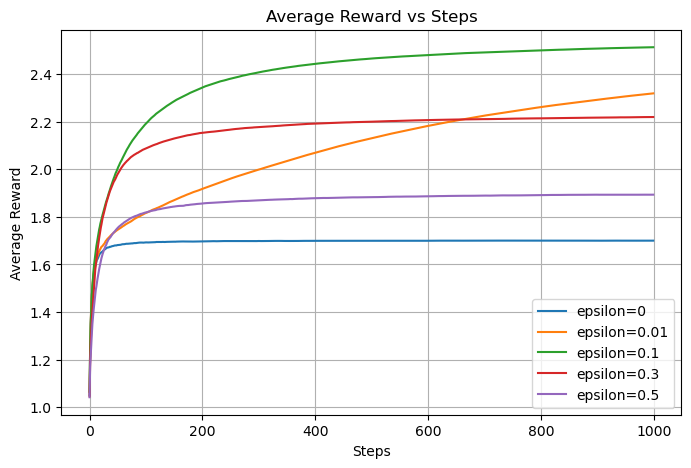

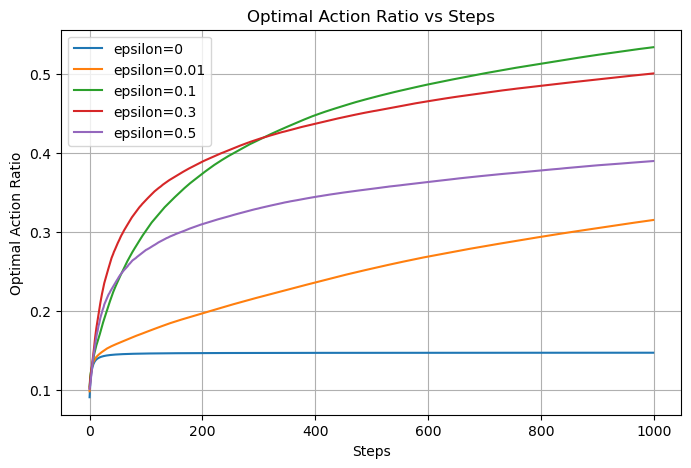

In [10]:
# Plot average reward
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(reward[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Steps")
plt.legend()
plt.grid(True)
plt.show()

# Plot optimal action ratio
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(optimal_ratio[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Optimal Action Ratio")
plt.title("Optimal Action Ratio vs Steps")
plt.legend()
plt.grid(True)
plt.show()

## reward std = 10.0 

In [13]:
config = KArmBanditsConfig(k=10, max_reward=3, min_reward=-3, reward_std=10.0)
bandits = initialize_bandits(config)

eps = [0, 0.01, 0.1, 0.3, 0.5]
reward = {}
optimal_ratio = {}
for e in eps:
    r, o = run_experiments(config.k, e, bandits, 3000, 2000)
    reward[e] = np.mean(r, axis=0)
    optimal_ratio[e] = np.mean(o, axis=0)

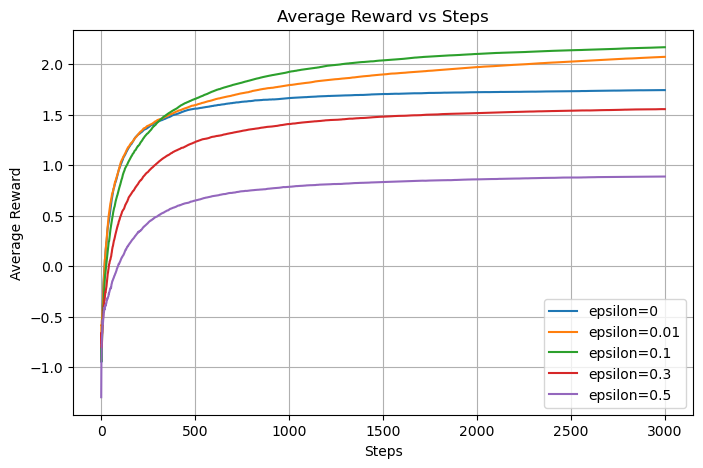

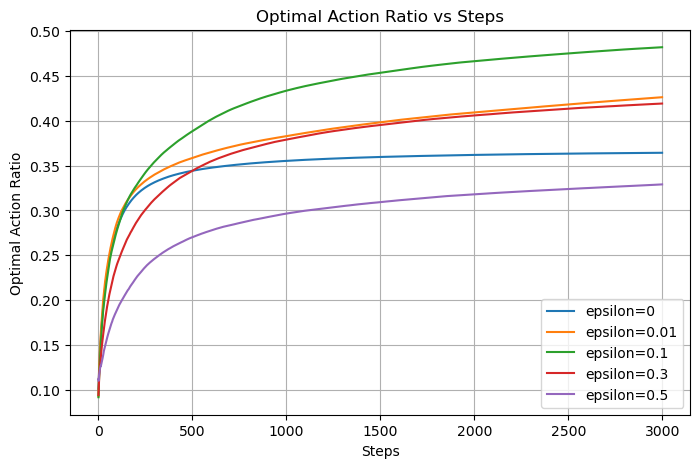

In [14]:
# Plot average reward
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(reward[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward vs Steps")
plt.legend()
plt.grid(True)
plt.show()

# Plot optimal action ratio
plt.figure(figsize=(8, 5))
for e in eps:
    plt.plot(optimal_ratio[e], label=f"epsilon={e}")
plt.xlabel("Steps")
plt.ylabel("Optimal Action Ratio")
plt.title("Optimal Action Ratio vs Steps")
plt.legend()
plt.grid(True)
plt.show()